# Figure 6a

9600
9600


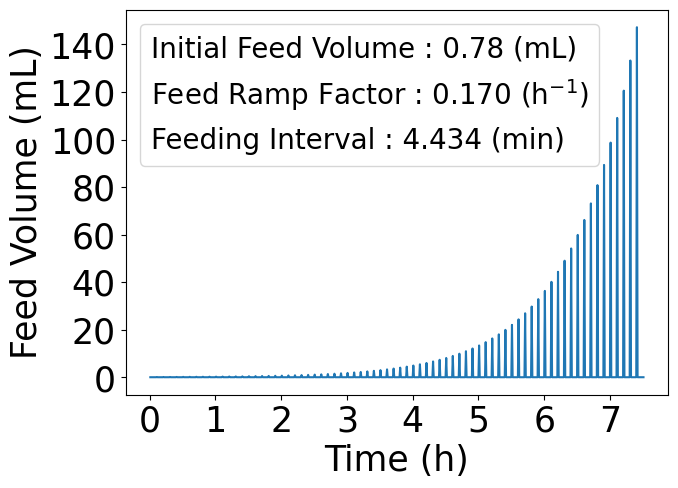

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils
import os

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
print(ns)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  config.MEDIA_TRANSFER_GAP # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            substrate_action = 0.01
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak= config.OPT_SUB_CELL_RATIO*1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break


import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Parameters
initial_volume = 9e-5       # Starting population
ramp_rate = 0.1             # Growth rate (e.g., 20% per iteration)

# Initialize variables
flow_volume = initial_volume
volumes = []
time_vector = tvec

# Simulate exponential growth
for i in range(ns):
    if i % media_transfer_step == 0 and i != 0:
        if sum(volumes) <= 1.5:
            flow_volume = flow_volume * math.exp(ramp_rate)  # Increase population exponentially
            volumes.append(flow_volume)
        else:
            volumes.append(0)
            break
    else:
        volumes.append(0)

print(len(time_vector))

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"

# Plotting
plt.figure(figsize=(7, 5))  # Set figure size
plt.plot(time_vector[:len(volumes)], np.array(volumes)*1e3)

# Add labels with fontsize 15
plt.xlabel("Time (h)", fontsize=25)
plt.ylabel("Feed Volume (mL)", fontsize=25)

# Define custom legend
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Initial Feed Volume : 0.78 (mL)'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=fr'Feed Ramp Factor : 0.170 (h$^{{-1}}$)'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'Feeding Interval : 4.434 (min)'),
]

# Add the custom legend
plt.xticks(fontsize=25)  # Set x-tick font size
plt.yticks(fontsize=25)  # Set y-tick font size
plt.legend(handles=custom_lines, fontsize=20, handlelength=0,handletextpad=0)  # Set legend font size
figure_path = os.path.join('figures','figure6','figure6a.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.show()


# Traditional controller comparison
# DOE vs BayesOpt

In [16]:
import matplotlib.pyplot as plt
import numpy as np
from bayesopt_vs_tc import run_simulation, objective, run_bayesopt
import os

run1 = run_bayesopt(n_trials=15, n_runs=20)
run2 = run_bayesopt(n_trials=22, n_runs=20)
run3 = run_bayesopt(n_trials=125, n_runs=20)

# Example enzyme activity data for both methods
bayesOpt_data = {
    15: run1, #3.10, #,
    22: run2,#3.13,#,
    125: run3 #3.21 #
}

DOE_data = {
    15: [2.6] * 20,
    22: [2.86] * 20 ,
    125: [3.17] * 20 ,
}


[I 2025-03-08 13:25:49,185] A new study created in memory with name: no-name-a9be91ee-03f7-434d-a048-f8afe4988e9e
[I 2025-03-08 13:25:49,363] Trial 0 finished with value: 0.4287364870516966 and parameters: {'start_volume': 0.0002573960866677739, 'feed_gap': 0.22033387025223664, 'ramp_factor': 0.06187759047056634}. Best is trial 0 with value: 0.4287364870516966.
[I 2025-03-08 13:25:49,409] Trial 1 finished with value: 0.20939927283140833 and parameters: {'start_volume': 0.00044312405111845396, 'feed_gap': 0.23240190208118627, 'ramp_factor': 0.29409937051635104}. Best is trial 0 with value: 0.4287364870516966.
[I 2025-03-08 13:25:49,527] Trial 2 finished with value: 2.5082390420662204 and parameters: {'start_volume': 0.0007343706492188177, 'feed_gap': 0.08174198516430048, 'ramp_factor': 0.031192053249902325}. Best is trial 2 with value: 2.5082390420662204.
[I 2025-03-08 13:25:49,544] Trial 3 finished with value: 0.0089033367839816 and parameters: {'start_volume': 0.0008161386237710621, '

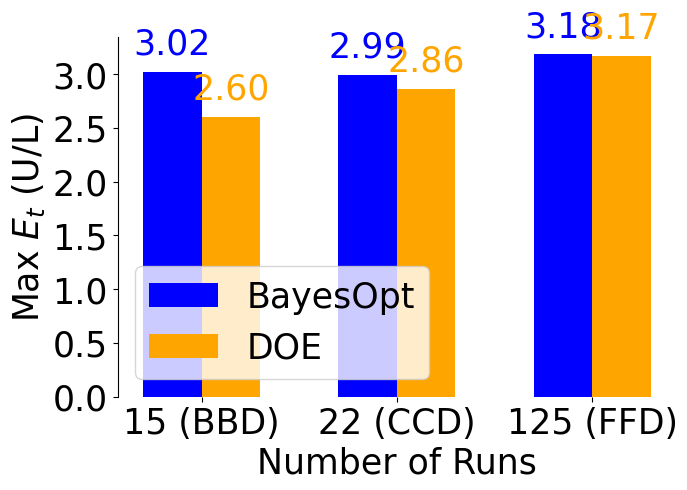

In [20]:
# Calculate means
means_bayesOpt = [np.max(bayesOpt_data[category]) for category in [15, 22, 125]]
means_doe = [np.max(DOE_data[category]) for category in [15, 22, 125]]

# Bar width
bar_width = 0.3
x = np.arange(len([15, 22, 125]))

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"

# Plot bars without error bars
bars1 = ax.bar(x - bar_width/2, means_bayesOpt, bar_width, label='BayesOpt', color='blue')
bars2 = ax.bar(x + bar_width/2, means_doe, bar_width, label='DOE', color='orange')

# Add labels and title
ax.set_xlabel('Number of Runs', fontsize=25)
ax.set_ylabel(r'Max $E_t$ (U/L)', fontsize=25)
ax.set_xticks(x)
ax.set_xticklabels(["15 (BBD)", "22 (CCD)", "125 (FFD)"], fontsize=25)  # Categories of runs
ax.legend(fontsize=25)

# Add mean values on top of the bars
for i, bar in enumerate(bars1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{means_bayesOpt[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='blue')  

for i, bar in enumerate(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{means_doe[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='orange')  

# Remove all spines except for the y-axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set tick font sizes
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Optimize layout to avoid overlapping
plt.tight_layout()

# Save figure
figure_path = os.path.join('figures','figure6','figure6b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)

# Display the plot
plt.show()


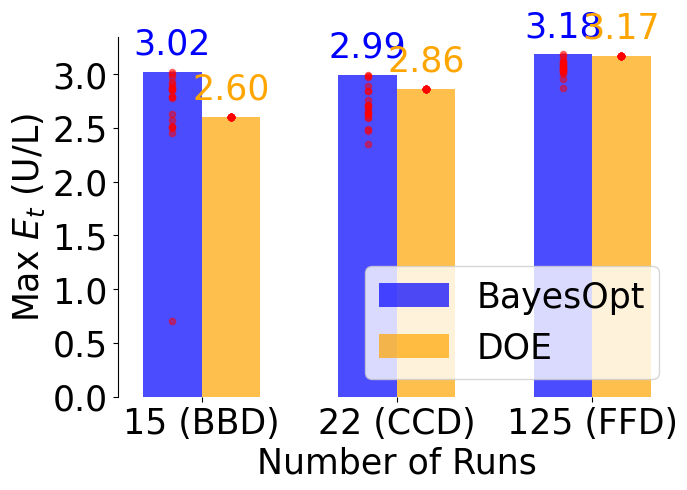

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Assuming bayesOpt_data and DOE_data are dictionaries with categories 15, 22, and 125
# Calculate maximum values for the bars
max_bayesOpt = [np.max(bayesOpt_data[category]) for category in [15, 22, 125]]
max_doe = [np.max(DOE_data[category]) for category in [15, 22, 125]]

# Calculate the other values (excluding max) to be plotted as scatter
scatter_bayesOpt = [bayesOpt_data[category] for category in [15, 22, 125]]
scatter_doe = [DOE_data[category] for category in [15, 22, 125]]

# Bar width
bar_width = 0.3
x = np.arange(len([15, 22, 125]))  # Positions for bars

# Create figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"

# Plot bars with max values
bars1 = ax.bar(x - bar_width/2, max_bayesOpt, bar_width, label='BayesOpt', color='blue', alpha=0.7)
bars2 = ax.bar(x + bar_width/2, max_doe, bar_width, label='DOE', color='orange', alpha=0.7)

# Plot scatter points for the other values (excluding max)
for i, category in enumerate([15, 22, 125]):
    ax.scatter([x[i] - bar_width/2] * len(scatter_bayesOpt[i]), scatter_bayesOpt[i], color='red', alpha=0.5, s=20)
    ax.scatter([x[i] + bar_width/2] * len(scatter_doe[i]), scatter_doe[i], color='red', alpha=0.5, s=20)

# Add labels and title
ax.set_xlabel('Number of Runs', fontsize=25)
ax.set_ylabel(r'Max $E_t$ (U/L)', fontsize=25)
ax.set_xticks(x)
ax.set_xticklabels(["15 (BBD)", "22 (CCD)", "125 (FFD)"], fontsize=25)  # Categories of runs
ax.legend(fontsize=25)

# Add mean values on top of the bars
for i, bar in enumerate(bars1):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{max_bayesOpt[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='blue')  

for i, bar in enumerate(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{max_doe[i]:.2f}', 
            ha='center', va='bottom', fontsize=25, color='orange')  

# Remove all spines except for the y-axis
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set tick font sizes
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Optimize layout to avoid overlapping
plt.tight_layout()

# Save figure
figure_path = os.path.join('figures','figure6','figure6b.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)

# Display the plot
plt.show()


# BayesOpt


Start flow volume 0.0007163778471238317
Feed Interval 0.16180828599166347
Ramp Factor 0.07296028394475211
 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  3.1836619975847453


<Figure size 700x500 with 0 Axes>

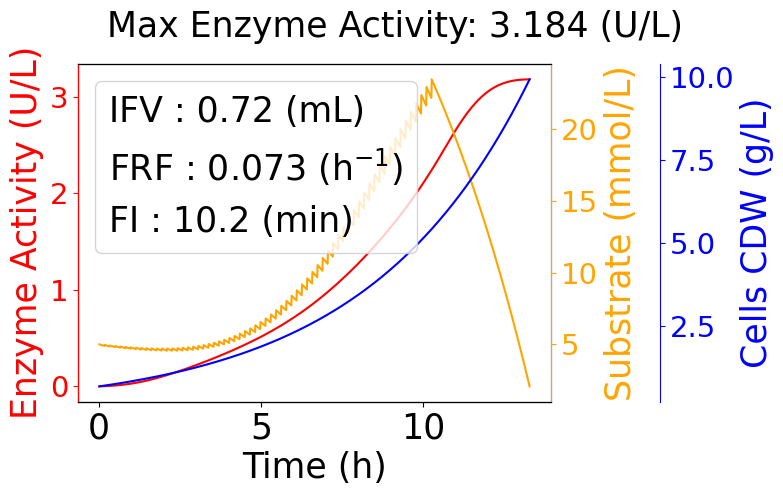

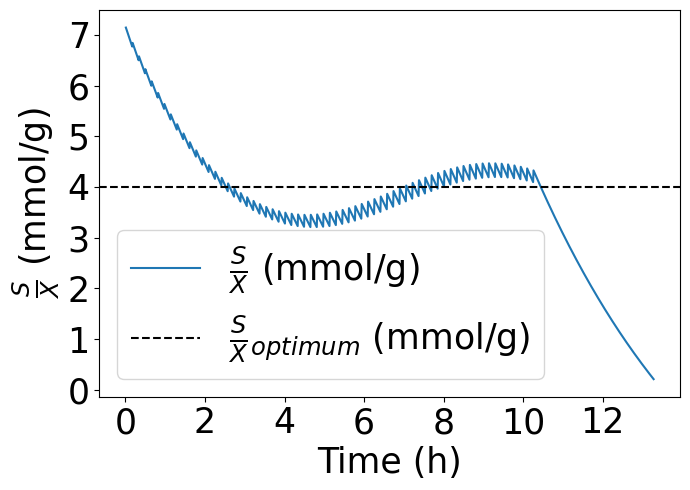

In [31]:
from matplotlib.lines import Line2D
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

# {'start_volume': 0.0007163778471238317, 'feed_gap': 0.16180828599166347, 'ramp_factor': 0.07296028394475211}

start_flow_volume = 0.0007163778471238317
feed_interval = 0.16180828599166347
ramp_factor = 0.07296028394475211

#print(f"------------- Experiment {index+1} ------------")
print(f"Start flow volume {start_flow_volume}")
print(f"Feed Interval {feed_interval}")
print(f"Ramp Factor {ramp_factor}")


initial_volume = start_flow_volume
flow_volume = initial_volume
ramp_rate = ramp_factor

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break


X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
plt.figure(figsize=(7,5))
max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))

fig, ax1 = plt.subplots(figsize=(8, 5))
fig.suptitle(f"Max Enzyme Activity: {max_enzyme} (U/L)", fontsize=25)

# Plot Enzyme Activity
ax1.plot(tvec[0:i], E, color="red", label="Enzyme Activity (U/L)")

# Substrate data on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S*1e3, color="orange", label="Substrate (mmol/L)")

# Cells data on tertiary y-axis
ax3 = ax1.twinx()
ax3.plot(tvec[0:i], X, color="blue", label="Cells CDW (g/L)")
ax3.spines['right'].set_position(('axes', 1.23))

# Axis labels with fontsize
ax1.set_ylabel("Enzyme Activity (U/L)", color="red", fontsize=25)
ax1.set_xlabel("Time (h)", fontsize=25)
ax2.set_ylabel("Substrate (mmol/L)", color="orange", fontsize=25)
ax3.set_ylabel("Cells CDW (g/L)", color="blue", fontsize=25)

# Tick parameters with fontsize and colors
ax1.tick_params(axis='y', colors="red", labelsize=21)
ax2.tick_params(axis='y', colors="orange", labelsize=21)
ax3.tick_params(axis='y', colors="blue", labelsize=21)
ax1.tick_params(axis='x', labelsize=25)

# Spines colors
ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")

# Custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'IFV : {start_flow_volume*1e3:.2f} (mL)'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=fr'FRF : {round(ramp_factor, 3)} (h$^{{-1}}$)'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'FI : 10.2 (min)'),
]

plt.legend(handles=custom_lines, fontsize=25,handlelength=0,handletextpad=0)
plt.tight_layout()
figure_path = os.path.join('figures','figure6','figure6c-1.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
# Second plot: Substrate to Cell Ratio
plt.figure(figsize=(7, 5))
plt.plot(tvec[:len(S_C_R)], S_C_R*1e3, label=r"$\frac{S}{X}$ (mmol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO*1e3, color="black", linestyle="--", label=r"$\frac{S}{X}_{optimum}$ (mmol/g)")
plt.xlabel("Time (h)", fontsize=25)
plt.ylabel(r"$\frac{S}{X}$ (mmol/g)", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.tight_layout()
figure_path = os.path.join('figures','figure6','figure6c-2.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()


# DOE Best Result

Start flow volume 0.0009
Feed Interval 0.2
Ramp Factor 0.085
 -----------------------------------------------------------------------
 ----------------------------  Results  --------------------------------
 MAX ENZYME ACTIVITY :  3.1697426367244446


<Figure size 700x500 with 0 Axes>

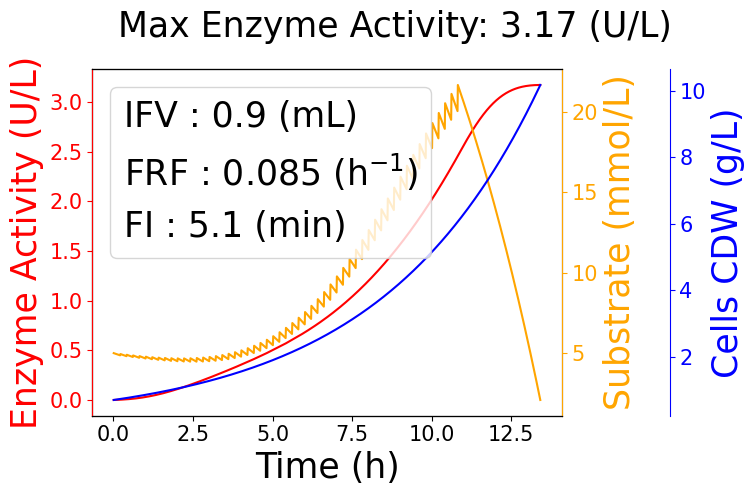

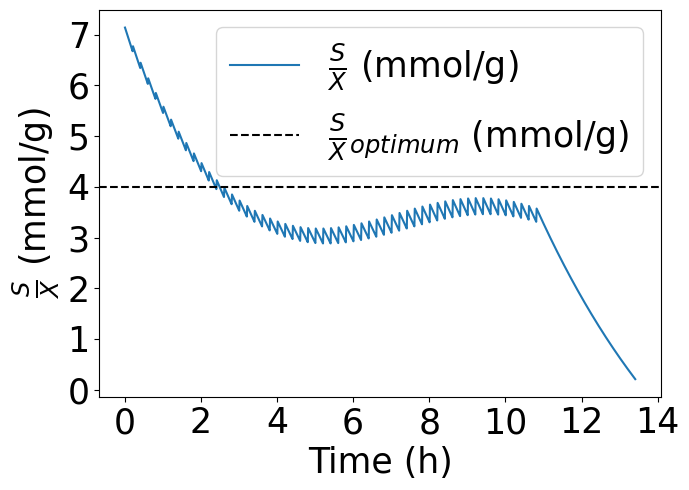

In [5]:
from matplotlib.lines import Line2D
import optuna
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import random 
import config
from scipy.interpolate import CubicSpline
import utils

start_flow_volume = 0.0009
feed_interval = 0.2
ramp_factor = 0.085

#print(f"------------- Experiment {index+1} ------------")
print(f"Start flow volume {start_flow_volume}")
print(f"Feed Interval {feed_interval}")
print(f"Ramp Factor {ramp_factor}")


initial_volume = start_flow_volume
flow_volume = initial_volume
ramp_rate = ramp_factor

# Initial conditions
X0 = config.X0  # CDW g/L 
S0 = config.S0 # mol/L
E0 = config.E0 # U/L 

# Process conditions
T = config.INIT_TEMPRATURE #'C 
T_opt = config.OPTIMUM_TEMPERATURE #'C
A = config.INIT_AGITATION # RPM

# model parameters
Ks = config.KS    # mol/L
Yxs =  config.YXS  # CDW g/mol
MuE_opt = config.MUE_OPT    # U/CDW g
mu_max = config.MU_MAX   # /h
del_t = config.DEL_T # hours ie. 36 seconds
t_end = config.T_END
total_sim_steps = int(t_end/del_t)
tvec = [del_t + i * del_t for i in range(total_sim_steps)]
ns = len(tvec)
kl = config.KL # mol/L
cell_death_timer = config.CELL_DEATH_TIMER
cell_death_time = config.CELL_DEATH_TIME

# Substrate addition calculations
tank_capacity = config.TANK_CAPACITY # L
substrate_in_tank_liters = config.SUBSTRATE_IN_TANK_LITERS # L
max_substrate_limit_liters = config.MAX_SUBSTRATE_LIMIT_LITERS # L
substrate_transfer_amount_liters = config.SUBSTRATE_TRANSFER_AMOUNT_LITERS # L 
media_transfer_gap =  feed_interval # Hours this is after 10 steps ie. 6 minutes
media_transfer_step = int(media_transfer_gap/del_t)
substrate_concentration = S0
sub_in_tank_moles = S0 * substrate_in_tank_liters # mol

# external media tank configurations
ext_tank_substrate_conc = config.EXT_TANK_SUBSTRATE_CONC # mol/L
substrate_transfer_moles = substrate_transfer_amount_liters * ext_tank_substrate_conc # mol 

# X S E delE delX, muE
D = np.zeros((ns+1, 6))
D[0][0] = X0
D[0][1] = substrate_concentration
D[0][2] = E0

for i in range(ns):
    X = D[i][0]
    S = D[i][1]
    E = D[i][2]

    MuX = utils.cell_growth_rate(S)
    # new cells that are generated
    dXdt = utils.cells_produced(X, MuX)

    # SUbstrate consumption
    dSdt = utils.substrate_consumed(dXdt)

    # Find change in cells 
    delX = dXdt * del_t
    # Update cells
    D[i+1][0] = X + delX
    
    # Find change in substrate
    delS = dSdt * del_t

    # # Update substrate
    if substrate_in_tank_liters < max_substrate_limit_liters:
        if i%(media_transfer_step) == 0 and i != 0:
            flow_volume *= math.exp(ramp_rate)
            substrate_action = flow_volume
            if True:
                # get substrate concentraion for current timestep
                substrate_concentration = S
                sub_in_tank_moles = substrate_concentration * substrate_in_tank_liters
                # Add substrate and calculate new concentraion
                substrate_in_tank_liters = substrate_in_tank_liters + substrate_action # Liters of media
                sub_in_tank_moles = sub_in_tank_moles + ext_tank_substrate_conc * substrate_action  # grams
                substrate_concentration = sub_in_tank_moles/substrate_in_tank_liters # substrate grams/liter
                S = substrate_concentration

    # Check if substrate is less than or close to 0
    if S + delS < 0.000001:
        D[i+1][1] = 0
    else:
        D[i+1][1] = S + delS

    # Enzyme determination 
    sub_cell_ratio = (S/X) * 1e6

    weibull = utils.get_weibull_y_value(sub_cell_ratio, peak=config.OPT_SUB_CELL_RATIO*1e6)
    MuE = MuE_opt * weibull

    if dXdt == 0:
        MuE = 0

    # new enzyme from fresh cells
    delE = MuE * X * del_t
    
    # Update enzyme variable
    D[i+1][2] = E + delE

    # terminate if tank capacity is full and cells start dying
    if substrate_in_tank_liters >= max_substrate_limit_liters and dXdt == 0:
        break


X = D[:,0][0:i]
S = D[:,1][0:i]
E = D[:,2][0:i]
MUE = D[:,5][0:i]
S_C_R = S/X
plt.figure(figsize=(7,5))
max_enzyme = round(max(E),3)
sub_max = round(max(S),3)
max_cells = round(max(X),3)
print(" -----------------------------------------------------------------------")
print(" ----------------------------  Results  --------------------------------")
print(" MAX ENZYME ACTIVITY : ", max(D[:,2]))
# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"

fig, ax1 = plt.subplots(figsize=(8, 5))
fig.suptitle(f"Max Enzyme Activity: {max_enzyme} (U/L)", fontsize=25)

# Plot Enzyme Activity
ax1.plot(tvec[0:i], E, color="red", label="Enzyme Activity (U/L)")

# Substrate data on secondary y-axis
ax2 = ax1.twinx()
ax2.plot(tvec[0:i], S*1e3, color="orange", label="Substrate (mmol/L)")

# Cells data on tertiary y-axis
ax3 = ax1.twinx()
ax3.plot(tvec[0:i], X, color="blue", label="Cells CDW (g/L)")
ax3.spines['right'].set_position(('axes', 1.23))

# Axis labels with fontsize
ax1.set_ylabel("Enzyme Activity (U/L)", color="red", fontsize=25)
ax1.set_xlabel("Time (h)", fontsize=25)
ax2.set_ylabel("Substrate (mmol/L)", color="orange", fontsize=25)
ax3.set_ylabel("Cells CDW (g/L)", color="blue", fontsize=25)

# Tick parameters with fontsize and colors
ax1.tick_params(axis='y', colors="red", labelsize=15)
ax2.tick_params(axis='y', colors="orange", labelsize=15)
ax3.tick_params(axis='y', colors="blue", labelsize=15)
ax1.tick_params(axis='x', labelsize=15)

# Spines colors
ax2.spines['right'].set_color("orange")
ax3.spines['right'].set_color("blue")
ax3.spines['left'].set_color("red")

# Custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'IFV : {round(start_flow_volume, 5)*1e3} (mL)'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=fr'FRF : {round(ramp_factor, 3)} (h$^{{-1}}$)'),
    Line2D([0], [0], color='none', marker=None, linestyle='None', label=f'FI : 5.1 (min)'),
]

plt.legend(handles=custom_lines, fontsize=25,handlelength=0,handletextpad=0)
plt.tight_layout()
figure_path = os.path.join('figures','figure6','figure6d-1.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=300)
plt.show()

# Set global font to Times New Roman
plt.rcParams["font.family"] = "DejaVu Sans"
# Second plot: Substrate to Cell Ratio
plt.figure(figsize=(7, 5))
plt.plot(tvec[:len(S_C_R)], S_C_R*1e3, label=r"$\frac{S}{X}$ (mmol/g)")
plt.axhline(y=config.OPT_SUB_CELL_RATIO*1e3, color="black", linestyle="--", label=r"$\frac{S}{X}_{optimum}$ (mmol/g)")
plt.xlabel("Time (h)", fontsize=25)
plt.ylabel(r"$\frac{S}{X}$ (mmol/g)", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.legend(fontsize=25)
plt.tight_layout()
figure_path = os.path.join('figures','figure6','figure6d-2.svg')
plt.savefig(figure_path, format="svg", bbox_inches="tight", dpi=900)
plt.show()